In [7]:

import seaborn as sns
import ast
import pandas as pd
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date']= pd.to_datetime(df.job_posted_date)
import matplotlib.pyplot as plt

df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)


In [13]:
df_DA_US = df[(df['job_country'] =='United States') & (df['job_title_short'] == 'Data Analyst')]

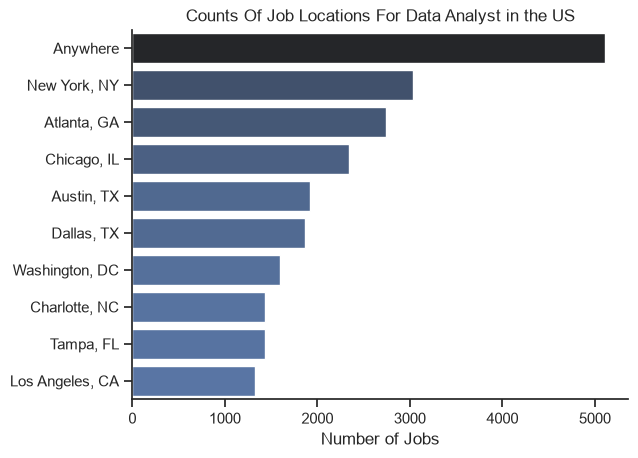

In [20]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')

sns.barplot(data=df_plot, x= 'count', y = 'job_location', hue= 'count' , palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts Of Job Locations For Data Analyst in the US')
plt.xlabel ( 'Number of Jobs')
plt.ylabel('')
plt.show()

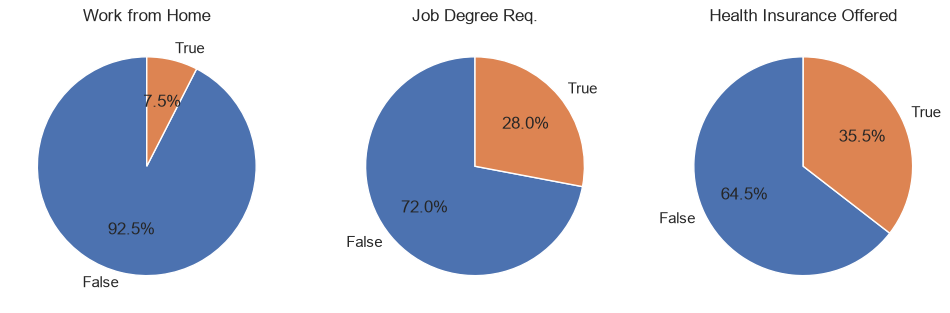

In [21]:
fig,ax = plt.subplots(1,3)

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention' : 'Job Degree Req.',
    'job_health_insurance' : 'Health Insurance Offered'
}


fig.set_size_inches(12, 5)

for i, (column, title) in enumerate(dict_column.items()):
      ax[i].pie(df_DA_US[column].value_counts(), startangle=90, autopct='%1.1f%%',labels=['False', 'True'])
      ax[i].set_title(title) 

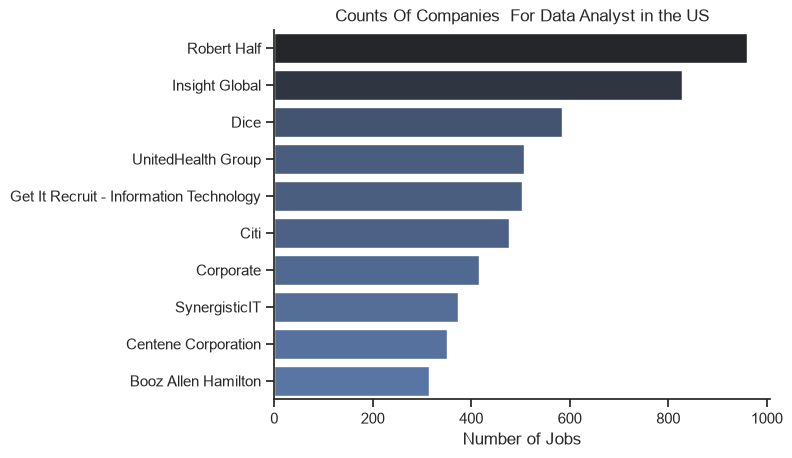

In [24]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')

sns.barplot(data=df_plot, x= 'count', y = 'company_name', hue= 'count' , palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts Of Companies  For Data Analyst in the US')
plt.xlabel ( 'Number of Jobs')
plt.ylabel('')
plt.show()